In [5]:
# =================
# Import Statements
# =================
import numpy as np
import pyomo.environ as pyo
from pyomo.environ import units
from formulation import Formulation

f = Formulation()
x = f.Variable(name="x" , guess = 5     , units = "-"  , size=2, description="x variable")
f.Objective(x[0]**2)
f.ConstraintList(
    [
        x[0] >= 2,
        x[1] == 1.0
    ])
from solver import cvxopt_solve
res = cvxopt_solve(f)
print(res['x'])

# [[0, 1.0, 2.0, 0.0], [1, 2.0, -1.0, 0.0], [2, 1.0, 0.0, 1.0], [2, 1.0, -0.0, -1.0]]

[ 2.00e+00]
[ 1.00e+00]



In [6]:
# =================
# Import Statements
# =================
import numpy as np
import pyomo.environ as pyo
from pyomo.environ import units
from formulation import Formulation

f = Formulation()
x = f.Variable(name="x" , guess = 5     , units = "-"  , description="x variable")
y = f.Variable(name="y" , guess = 5     , units = "-"  , description="y variable")
f.Objective(x**2)
f.ConstraintList(
    [
        x >= 2,
        # 1 >= 2 * x**-1
        y == 5.0
        # 1 >= y**1
        # 1 >= y**-1
        # y>=1
    ])
from solver import cvxopt_solve
res = cvxopt_solve(f)
print(res['x'])


[ 2.00e+00]
[ 5.00e+00]



In [2]:
import numpy as np
import pyomo.environ as pyo
from pyomo.environ import units
from formulation import Formulation

f = Formulation()

x   = f.Variable(name = 'x', guess = 1, units = '-', size = 0, description = 'The X variable')
y   = f.Variable(name = 'y', guess = 1, units = '-', size = 0, description = 'The Y variable')
z   = f.Variable(name = 'z', guess = 1, units = '-', size = 0, description = 'The Z variable')
cst = f.Constant(name = 'c', value = 2.0, units = '-', size = 0, description = 'A constant')

f.Objective(
               y**2 + x
           )

f.ConstraintList([
    y >= 4,
    x >= 1,
    # y >= 1,
              ])

from solver import cvxopt_solve
res = cvxopt_solve(f)
print(res)
print(res['x'])


ValueError: Rank(A) < p or Rank([H(x); A; Df(x); G]) < n

In [12]:
import copy
import numpy as np
from corsair import units
from corsair.optimization.variable import Variable
from corsair.optimization import Formulation, Constant

x   = Variable(name = 'x', guess = 1, units = '-', size = 0, description = 'The X variable')
y   = Variable(name = 'y', guess = 1, units = '-', size = 0, description = 'The Y variable')
z   = Variable(name = 'z', guess = 1, units = '-', size = 0, description = 'The Z variable')
cst = Constant(name = 'c', value = 2.0, units = '-', size = 0, description = 'A constant')

objective = y * x
constraints = [
    x >= 1,
    y >= 1,
              ]

f = Formulation(objective, constraints)
from corsair.optimization.solve import solve
# f.solverOptions.solveType = 'qp'
f.solverOptions.solver = 'cvxopt'
# f.solverOptions.tol = 1e-8
rs = solve(f)
print(rs.result(5))
# print(rs.__dict__.keys())
# print(len(rs.intermediateSolves))

ValueError: Rank(A) < p or Rank([P; A; G]) < n

In [9]:
# ===========
# Description
# ===========
# A simple aircraft sizing problem, formulated as a Geometric Program
# From:  Hoburg and Abbeel
#        Geometric Programming for Aircraft Design Optimization
#        AIAA Journal
#        2014

# =================
# Import Statements
# =================
import numpy as np
import pyomo.environ as pyo
from pyomo.environ import units
from pyomo.contrib.edi import Formulation
from pyomo.contrib.edi import BlackBoxFunctionModel

# ===================
# Declare Formulation
# ===================
f = Formulation()

# =================
# Declare Variables
# =================

A   = f.Variable(name="A"   , guess = 10.0     , units = "-"   , description="aspect ratio")
C_D = f.Variable(name="C_D" , guess = 0.025    , units = "-"   , description="Drag coefficient of wing")
C_f = f.Variable(name="C_f" , guess = 0.003    , units = "-"   , description="skin friction coefficient")
C_L = f.Variable(name="C_L" , guess = 0.5      , units = "-"   , description="Lift coefficient of wing")
D   = f.Variable(name="D"   , guess = 300      , units = "N"   , description="total drag force")
Re  = f.Variable(name="Re"  , guess = 3e6      , units = "-"   , description="Reynold's number")
S   = f.Variable(name="S"   , guess = 10.0     , units = "m^2" , description="total wing area")
V   = f.Variable(name="V"   , guess = 30.0     , units = "m/s" , description="cruising speed")
W   = f.Variable(name="W"   , guess = 10000.0  , units = "N"   , description="total aircraft weight")
W_w = f.Variable(name="W_w" , guess = 2500     , units = "N"   , description="wing weight")

# =================
# Declare Constants
# =================
C_Lmax      = f.Constant( name="C_Lmax"  , value=2.0     , units="-"      , description="max CL with flaps down")
CDA0        = f.Constant( name="CDA0"    , value=0.0306  , units="m^2"    , description="fuselage drag area")
e           = f.Constant( name="e"       , value=0.96    , units="-"      , description="Oswald efficiency factor")
k           = f.Constant( name="k"       , value=1.2     , units="-"      , description="form factor")
mu          = f.Constant( name="mu"      , value=1.78e-5 , units="kg/m/s" , description="viscosity of air")
N_ult       = f.Constant( name="N_ult"   , value=2.5     , units="-"      , description="ultimate load factor")
rho         = f.Constant( name="rho"     , value=1.23    , units="kg/m^3" , description="density of air")
S_wetratio  = f.Constant( name="Srat"    , value=2.05    , units="-"      , description="wetted area ratio")
tau         = f.Constant( name="tau"     , value=0.12    , units="-"      , description="airfoil thickness to chord ratio")
V_min       = f.Constant( name="V_min"   , value=22      , units="m/s"    , description="takeoff speed")
W_0         = f.Constant( name="W_0"     , value=4940.0  , units="N"      , description="aircraft weight excluding wing")
W_W_coeff1  = f.Constant( name="W_c1"    , value=8.71e-5 , units="1/m"    , description="Wing Weight Coefficient 1")
W_W_coeff2  = f.Constant( name="W_c2"    , value=45.24   , units="Pa"     , description="Wing Weight Coefficient 2" )

# =====================
# Declare the Objective
# =====================
f.Objective(D)

# ===================================
# Declare some intermediate variables
# ===================================
pi = np.pi
C_D_fuse = CDA0 / S
C_D_wpar = k * C_f * S_wetratio
C_D_ind = C_L**2 / (pi * A * e)
W_w_strc = W_W_coeff1 * (N_ult * A**1.5 * (W_0 * W * S) ** 0.5) / tau
W_w_surf = W_W_coeff2 * S

# =======================
# Declare the Constraints
# =======================
f.ConstraintList(
    [
        C_D >= C_D_fuse + C_D_wpar + C_D_ind,
        W_w >= W_w_surf + W_w_strc,
        D >= 0.5 * rho * S * C_D * V**2,
        Re == (rho / mu) * V * (S / A) ** 0.5,
        C_f == 0.074 / Re**0.2,
        W == 0.5 * rho * S * C_L * V**2,
        W == 0.5 * rho * S * C_Lmax * V_min**2,
        W >= W_0 + W_w,
    ])

# =======================
# Print Model
# =======================
# f.pprint()

from solver import cvxopt_solve
res = cvxopt_solve(f)
print(res)

# from pyomo.environ import SolverFactory
# opt = SolverFactory('ipopt')
# opt.solve(f)
# # print('The drag of the aircraft is %f N'%(f.D.value))

import pyomo
var_list = f.get_variables()
ctr = 0
for var in var_list:
    if isinstance(var,pyomo.core.base.var.IndexedVar):
        for ix in var.index_set():
            lbls = ["out","ret","sprint"]
            # print('%s[%s]:  %.4f  %s'%(var.name,lbls[ix],var[ix].value,var._units))
            print('%s[%s]:  %.4f  %s'%(var.name,lbls[ix],res['x'][ctr],var._units))
            ctr += 1
    else:
        print('%s:  %.4f  %s'%(var.name,res['x'][ctr],var._units))
        ctr += 1

{'status': 'optimal', 'primal objective': 254.87206433986776, 'dual objective': 254.8737060067865, 'x': <10x1 matrix, tc='d'>, 'y': <4x1 matrix, tc='d'>, 'z': <13x1 matrix, tc='d'>, 's': <12x1 matrix, tc='d'>, 'N_cons_total': 8, 'N_cons_noBounds': 8, 'N_cons_bounds': 0, 'inequality_unscramble': [0, 1, 2, 3, 8], 'equality_unscramble': [4, 5, 6, 7], 'problem_structure': 'geometric_program'}
A:  12.7002  dimensionless
C_D:  0.0231  dimensionless
C_f:  0.0039  dimensionless
C_L:  0.6513  dimensionless
D:  254.8721  N
Re:  2597092.8186  dimensionless
S:  12.0712  m**2
V:  38.5508  m/s
W:  7186.2160  N
W_w:  2246.2270  N


In [3]:

from ada.analysis.apis.xfoil.run import run
from ada.geometry.airfoils.kulfan import Kulfan
import os

PATH_TO_ADA = os.environ['PATH_TO_ADA']

def generateAirfoil(aflString):
    aflString = aflString.replace(' ','')
    aflString = aflString.lower()
    if aflString[0:4].lower() == 'naca':
        nacaNumbers = aflString[4:]
        if len(nacaNumbers) != 4:
            return 'Error: invalid naca4'
        else:
            afl1 = Kulfan() 
            afl1.naca4_like(int(nacaNumbers[0]), int(nacaNumbers[1]), int(nacaNumbers[2:]))
    else:
        afl1 = Kulfan()
        airfoil_directories = [
            PATH_TO_ADA + 'ada/geometry/airfoil_scraping/raw_airfoil_files/uiuc_airfoils',
            PATH_TO_ADA + 'ada/geometry/airfoil_scraping/raw_airfoil_files/airfoiltools_airfoils',
            PATH_TO_ADA + 'ada/geometry/airfoil_files',
        ]

        airfoil_directory_data = {}
        for afl_dir in airfoil_directories:
            pth = afl_dir
            combined = os.listdir(pth)
            files = [f for f in combined if os.path.isfile(pth + os.sep + f)]
            for fl in files:
                airfoil_directory_data[fl] = pth + os.sep + fl

        search_file = aflString + '.dat'
        afl1.fit2file(airfoil_directory_data[search_file])

    return afl1

airfoil = "naca2412"
angle_of_attack = 4
mach_number = 0.2
reynolds_number = 1e6
xtp_u = 0.2
xtp_l = 0.4
n_panels = 160
max_iter = 200
n_crit = 9.0
polar_file = "polars.txt"
bl_file = "bl_data.txt"
cp_file = "cp_data.txt"

afl = generateAirfoil(airfoil)

res = run(
    mode="alpha", 
    upperKulfanCoefficients=afl.upperCoefficients,
    lowerKulfanCoefficients=afl.lowerCoefficients,
    val=angle_of_attack, 
    Re=reynolds_number, 
    M=mach_number, 
    N_panels=n_panels, 
    N_crit=n_crit, 
    xtp_u=xtp_u,
    xtp_l=xtp_l,
    # polar_file=polar_file,
    # bl_file=bl_file,
    # cp_file=cp_file,
    max_iter=max_iter
)
print(res)

{'cd': 0.00975, 'cl': 0.6441, 'alpha': 4.0, 'cm': -0.0397, 'xtp_top': 0.2, 'xtp_bot': 0.4, 'xtr_top': 0.2, 'xtr_bot': 0.4, 'Re': 1000000.0, 'M': 0.2, 'N_crit': 9.0, 'N_panels': 160, 'cp_data': {'x': [1.0, 0.99181, 0.98073, 0.96795, 0.95381, 0.93873, 0.92308, 0.90712, 0.89099, 0.87479, 0.85855, 0.84229, 0.82603, 0.80977, 0.7935, 0.77724, 0.76098, 0.74471, 0.72843, 0.71214, 0.69584, 0.67954, 0.66322, 0.64689, 0.63055, 0.61421, 0.59787, 0.58153, 0.5652, 0.54889, 0.53259, 0.51631, 0.50006, 0.48384, 0.46766, 0.45152, 0.43543, 0.41938, 0.40338, 0.38743, 0.37154, 0.3557, 0.33992, 0.3242, 0.30855, 0.29296, 0.27745, 0.262, 0.24665, 0.23138, 0.21622, 0.20118, 0.18628, 0.17153, 0.15699, 0.14268, 0.12867, 0.11505, 0.10191, 0.08941, 0.07771, 0.06696, 0.05731, 0.04879, 0.04138, 0.03499, 0.02948, 0.02474, 0.02064, 0.01709, 0.014, 0.0113, 0.00896, 0.00693, 0.00519, 0.00371, 0.00249, 0.00152, 0.0008, 0.00031, 5e-05, 1e-05, 0.0002, 0.00064, 0.00135, 0.00232, 0.00355, 0.00505, 0.00682, 0.00886, 0.01119, 

0.49995421373787935
-7.588260378870485e-16


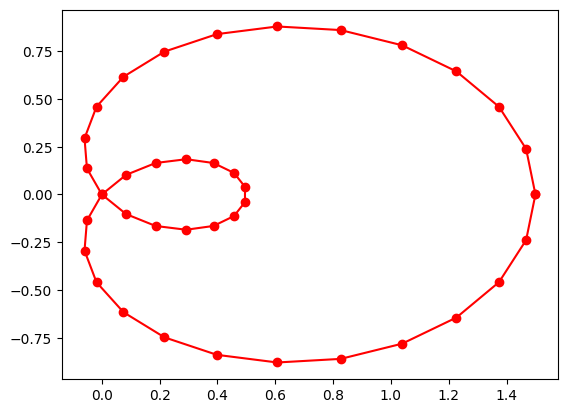

In [19]:
import numpy as np
phi = np.linspace(0, 2.*np.pi, 40)
r = 0.5 + np.cos(phi)         # polar coords
x, y = r * np.cos(phi), r * np.sin(phi)    # convert to cartesian

from scipy.interpolate import splprep, splev

# Fit the data of the airfoil x,y
tck, u = splprep([x, y], s=0)
# We plug in this u, and don't get correct x,y
new_points = splev(u, tck)



def residual_2(uguess):
    # Guess u
    u_guess=0.5
    
    #evaluate x,y @ uguess
    x_g, y_g = splev(u_guess,tck)
    print(x_g)
    print(y_g)
    return x_data[i]-x_g

for x in x_data:
    find u_guess that makes x_g == x

    Gives us U value for each coordinate x[i],y[i]

# choose n number of control points
#override c in tck to have N number of control points
# use the u values at our x, y coordinates
new_points = splev(u, tck)



Pick our guess nodes (set N to a choice), we have 0,0 and 1,0
Generate the spline using Bspline
splprep points generated from Bspline
find the Ucoordinates for each x_data using a spo.minimize
splev @ proper Ucoord --> x_data, y_spl 
minimise ssq(y_spl, ydata)



spo.minimize

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(x, y, 'ro')
ax.plot(new_points[0], new_points[1], 'r-')
plt.show()